<b><font size="6">OBISITY ML PROJECT</font></b><br><br>

<b style="color: red;">Import Library</font></b><br><br>

In [1]:
#%pip install numpy pandas seaborn scipy scikit-learn

In [2]:
# standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

# Scipy
from scipy.stats import uniform, randint 

# Sklearn - Feature Selection
from sklearn.feature_selection import mutual_info_classif, RFE

# Sklearn - Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Sklearn - Imputation
from sklearn.impute import KNNImputer, SimpleImputer

# Sklearn - model Selection
from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

# Sklearn - Linear Model 
from sklearn.linear_model import (
    Lasso,
    LinearRegression,
    LogisticRegression
)

# Sklearn - Classification Models 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.naive_bayes import GaussianNB

# Sklearn - Metrics 
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    make_scorer
)

# Plot settings / Warmning ignoring
sns.set_palette("flare")
warnings.simplefilter(action='ignore', category=FutureWarning)


<a class="anchor" id="">

# Import Data 
</a>

In [3]:
test = pd.read_csv(r"C:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\data\obesity_test.csv")
train = pd.read_csv(r"C:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\data\obesity_train.csv")

<a class="anchor" id="">

# Explore Data 

</a>

In [4]:
train.head()

,id,age,alcohol_freq,caloric_freq,devices_perday,eat_between_meals,gender,height,marrital_status,meals_perday,...,parent_overweight,physical_activity_perweek,region,siblings,smoke,transportation,veggies_freq,water_daily,weight,obese_level
0,1,21.0,Never,no,up to 5,Sometimes,Female,1.62,NaN,3.0,...,yes,NaN,LatAm,3.0,no,Public,Sometimes,1 to 2,64.0,Normal_Weight
1,2,23.0,Frequently,no,up to 5,Sometimes,Male,1.80,NaN,3.0,...,yes,3 to 4,LatAm,0.0,no,Public,Sometimes,1 to 2,77.0,Normal_Weight
2,3,NaN,Frequently,no,up to 2,Sometimes,Male,1.80,NaN,3.0,...,no,3 to 4,LatAm,2.0,no,Walk,Always,1 to 2,87.0,Overweight_Level_I
3,4,22.0,Sometimes,no,up to 2,Sometimes,Male,1.78,NaN,1.0,...,no,NaN,LatAm,3.0,no,Public,Sometimes,1 to 2,90.0,Overweight_Level_II
4,5,22.0,Sometimes,no,up to 2,Sometimes,Male,1.64,NaN,3.0,...,no,5 or more,LatAm,3.0,no,Public,Sometimes,1 to 2,53.0,Normal_Weight


In [5]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1611.0,NaN,NaN,NaN,806.0,465.199957,1.0,403.5,806.0,1208.5,1611.0
age,1545.0,NaN,NaN,NaN,24.344984,6.474498,6.0,20.0,23.0,26.0,88.0
alcohol_freq,1575,4,Sometimes,1057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
caloric_freq,1591,2,yes,1400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
devices_perday,1589,3,up to 2,708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eat_between_meals,1552,4,Sometimes,1306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1591,2,Male,826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,1597.0,NaN,NaN,NaN,1.704108,0.095567,1.29,1.63,1.7,1.77,2.19
marrital_status,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
meals_perday,1602.0,NaN,NaN,NaN,2.684145,0.817584,1.0,3.0,3.0,3.0,4.0


In [6]:
# The % of missing values in each column

for col in train.columns:
    pct_missing = np.mean(train[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

id - 0%
age - 4%
alcohol_freq - 2%
caloric_freq - 1%
devices_perday - 1%
eat_between_meals - 4%
gender - 1%
height - 1%
marrital_status - 100%
meals_perday - 1%
monitor_calories - 2%
parent_overweight - 1%
physical_activity_perweek - 35%
region - 4%
siblings - 1%
smoke - 1%
transportation - 2%
veggies_freq - 2%
water_daily - 2%
weight - 3%
obese_level - 0%


In [7]:
# The different values for each column to help decide what encoding to use

for col in train.columns:
    print(f"Unique values in '{col}':")
    print(train[col].unique())
    print()

Unique values in 'id':
[   1    2    3 ... 1609 1610 1611]

Unique values in 'age':
[21. 23. nan 22. 24. 41. 27. 52. 20. 19. 39. 30. 25. 29. 26. 38. 18. 17.
 15. 61. 44. 31. 34. 36. 32.  6. 40. 35. 45. 33. 51. 28. 16. 37. 42. 43.
 46. 55. 47. 88.]

Unique values in 'alcohol_freq':
<StringArray>
['Never', 'Frequently', 'Sometimes', 'Always', nan]
Length: 5, dtype: str

Unique values in 'caloric_freq':
<StringArray>
['no', 'yes', nan]
Length: 3, dtype: str

Unique values in 'devices_perday':
<StringArray>
['up to 5', 'up to 2', 'more than 5', nan]
Length: 4, dtype: str

Unique values in 'eat_between_meals':
<StringArray>
['Sometimes', 'Frequently', 'Never', 'Always', nan]
Length: 5, dtype: str

Unique values in 'gender':
<StringArray>
['Female', 'Male', nan]
Length: 3, dtype: str

Unique values in 'height':
[1.62 1.8  1.78 1.64 1.72 1.65 1.93 1.69 1.6  1.85 1.7  1.75 1.68 1.77
 1.79 1.5   nan 1.67 1.66 1.81 1.53 1.82 1.55 1.61 1.76 1.63 1.52 1.56
 1.57 1.58 1.87 1.89 1.74 2.19 1.83 1.92 

In [8]:
print(train.shape)
print(test.shape)

(1611, 21)
(500, 20)


In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1611 entries, 0 to 1610
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1611 non-null   int64  
 1   age                        1545 non-null   float64
 2   alcohol_freq               1575 non-null   str    
 3   caloric_freq               1591 non-null   str    
 4   devices_perday             1589 non-null   str    
 5   eat_between_meals          1552 non-null   str    
 6   gender                     1591 non-null   str    
 7   height                     1597 non-null   float64
 8   marrital_status            0 non-null      float64
 9   meals_perday               1602 non-null   float64
 10  monitor_calories           1572 non-null   str    
 11  parent_overweight          1591 non-null   str    
 12  physical_activity_perweek  1046 non-null   str    
 13  region                     1544 non-null   str    
 14  sib

In [10]:
# Value counts for each categorical column
cols = [col for col in train.columns if train[col].dtype == 'str']
train[cols] = train[cols].astype('object')

categorical_cols = train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Value counts for {col}:\n{train[col].value_counts()}\n")

Value counts for alcohol_freq:
alcohol_freq
Sometimes     1057
Never          466
Frequently      51
Always           1
Name: count, dtype: int64

Value counts for caloric_freq:
caloric_freq
yes    1400
no      191
Name: count, dtype: int64

Value counts for devices_perday:
devices_perday
up to 2        708
up to 5        696
more than 5    185
Name: count, dtype: int64

Value counts for eat_between_meals:
eat_between_meals
Sometimes     1306
Frequently     170
Never           41
Always          35
Name: count, dtype: int64

Value counts for gender:
gender
Male      826
Female    765
Name: count, dtype: int64

Value counts for monitor_calories:
monitor_calories
no     1501
yes      71
Name: count, dtype: int64

Value counts for parent_overweight:
parent_overweight
yes    1309
no      282
Name: count, dtype: int64

Value counts for physical_activity_perweek:
physical_activity_perweek
1 to 2       595
3 to 4       360
5 or more     91
Name: count, dtype: int64

Value counts for region:
r

In [11]:
# Check to see if we have to deal with any duplication

train.duplicated().sum()

np.int64(0)

### Findings

##### From the exploration I found that:
- Marital_status and Region variables can be dropped as all values are missing.
- Physical_activity_perweek has a very high % of missing values so I will take more care filling them in as this could be an important feature.
- Every other column has minimal missing values.
- We are not dealing with duplicated rows.
- A lot of the columns need to be encoded for use in models.
- A lot of the categorical columns have an option with far higher frequencies.


<a class="anchor" id="">

# Data Visualizations 

</a>

In [12]:
desired_order = ['Insufficient_Weight',
                 'Normal_Weight',
                 'Overweight_Level_I',
                 'Overweight_Level_II',
                 'Obesity_Type_I',
                 'Obesity_Type_II',
                 'Obesity_Type_III']

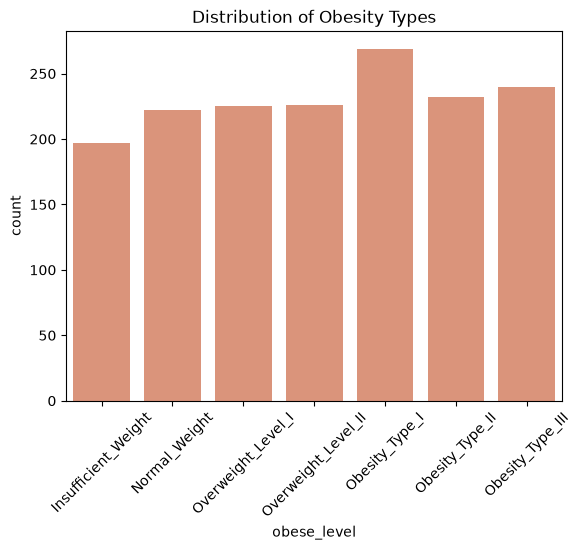

In [13]:
# Indicating how the different obesity types are distributed overall
sns.countplot(data=train, x='obese_level', order=desired_order)
plt.title('Distribution of Obesity Types')
plt.xticks(rotation=45)
plt.show()

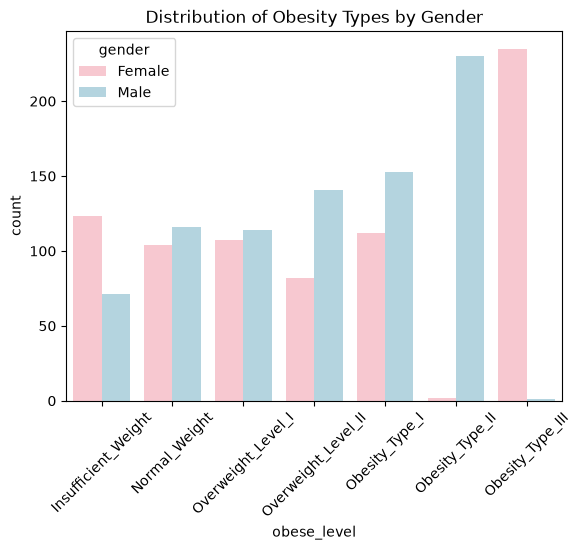

In [14]:
# Distribution of obesity types based on gender 

sns.countplot(data=train, x='obese_level', hue='gender', palette=['pink', 'lightblue'], order=desired_order)
plt.title('Distribution of Obesity Types by Gender')
plt.xticks(rotation=45)
plt.show()

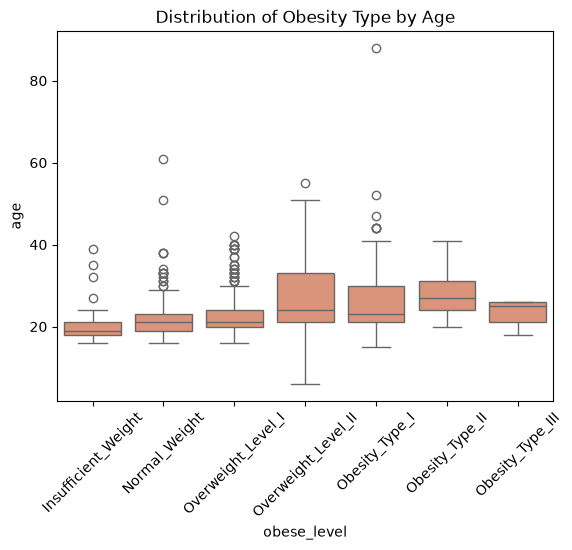

In [15]:
# Distributoion of obesity types based on age 
sns.boxplot(data=train, x='obese_level', y='age', order=desired_order)
plt.title('Distribution of Obesity Type by Age')
plt.xticks(rotation=45)
plt.show()

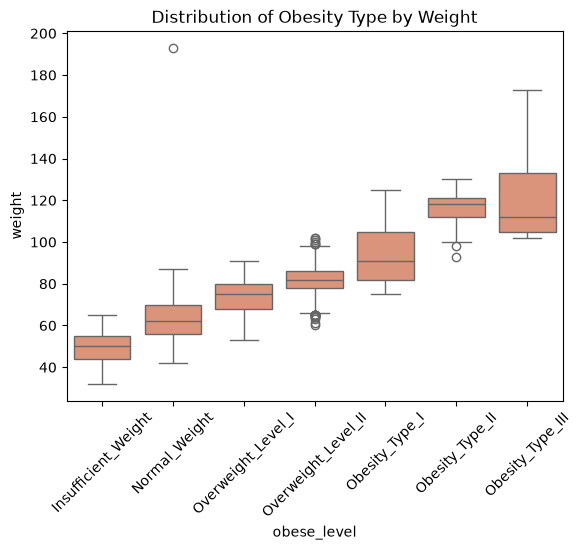

In [16]:
# Ditribution of obesity typed based on weights

sns.boxplot(data=train, x='obese_level', y='weight', order=desired_order)
plt.title('Distribution of Obesity Type by Weight')
plt.xticks(rotation=45)
plt.show()

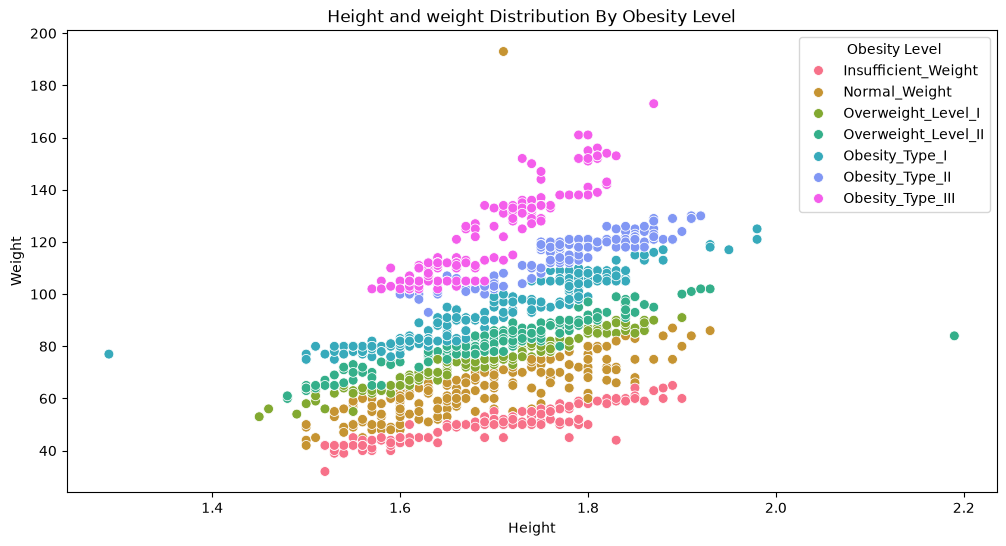

In [17]:
# Shows height and weight distribution by obesity level 

plt.figure(figsize=(12, 6))
sns.scatterplot(data=train, x='height', y='weight', hue='obese_level', s=50, hue_order=desired_order)
plt.title('Height and weight Distribution By Obesity Level')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend(title='Obesity Level')
plt.show()

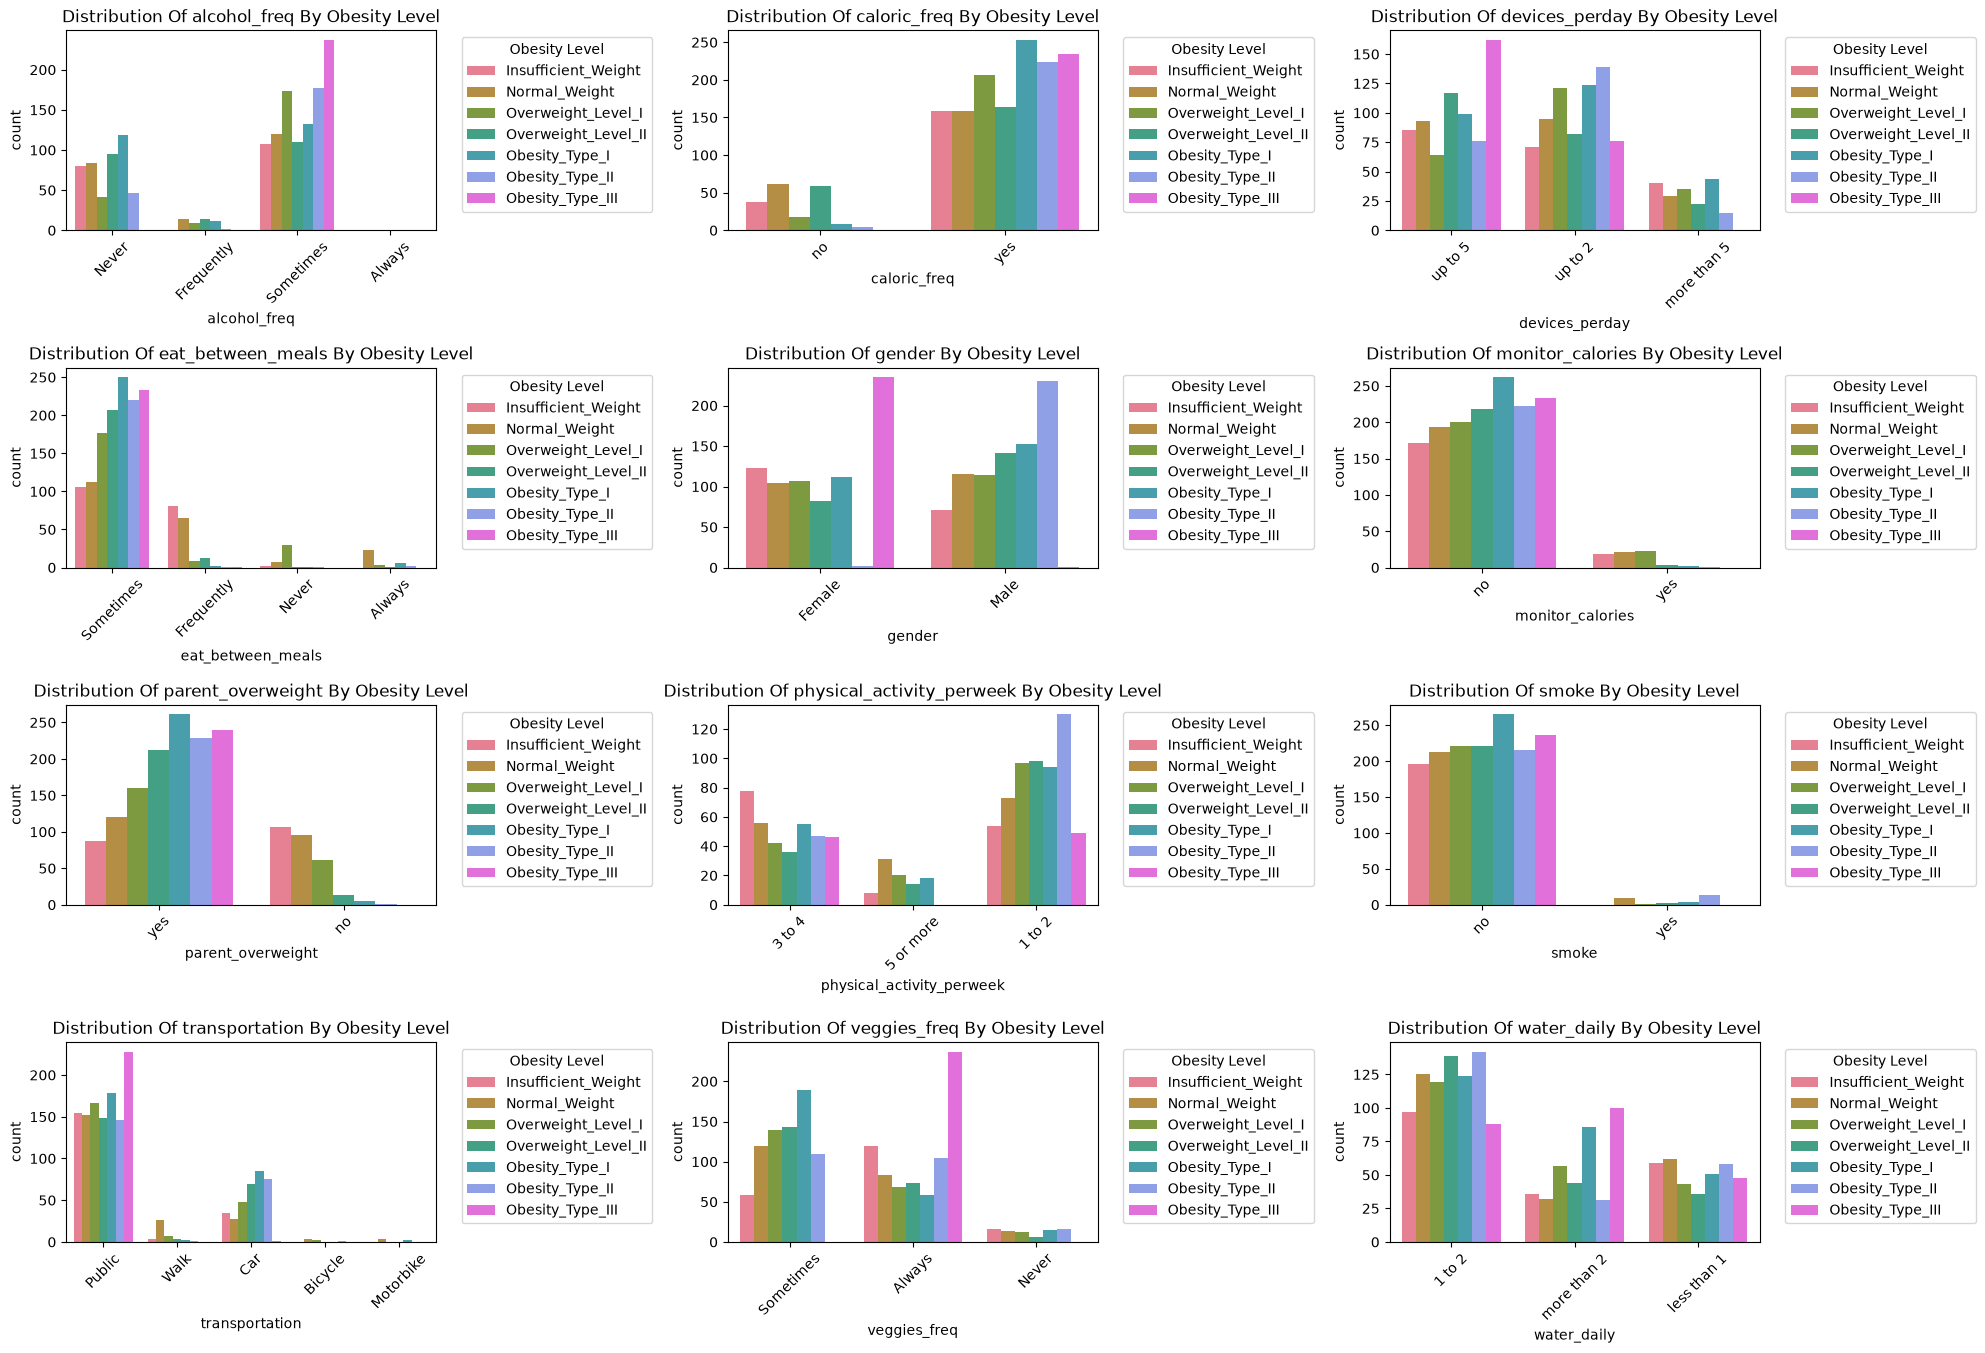

In [18]:
# Shows distribution of all categorical columns againts the different obesity types

categorical_cols = [col for col in train.columns if train[col].dtype == 'object']
categories = [col for col in categorical_cols if col not in ['obese_level', 'region']]

plt.figure(figsize=(20, 16))
for i, var in enumerate(categories, 1):
    plt.subplot(5, 3, i) 
    sns.countplot(data=train, x=var, hue='obese_level', hue_order=desired_order)
    plt.title(f'Distribution Of {var} By Obesity Level')
    plt.xticks(rotation=45)
    plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Findings 

##### From my visualizations I've found that: 

- Obesity type 1 is the most common 
- Gender distribution shows notable differences
- Most of the classes lie between ages 20-40 for all types (could show that age is negligble)
- Height and weight seem to be useful based on the cluters shows 
- We have normal weight, obese level I and II outliers that need to be removed due to logical reasoning
- Higher obesity level shows less physical activity levels
- Some columns showing similar patterns/ little variation showing that they may need to be removed
- I also have an idea on highly correlated features that can be useful later.


<a class="anchor" id="">

# Data Preprocessing 

</a>

In [22]:
# Drop the useless columns and outlier 

train = train.drop(train[train['obese_level'] == 'Normal_Weight']['weight'].idxmax())

train.drop('region', axis=1, inplace=True)  # All the same values
train.drop('marrital_status', axis=1, inplace=True) # All NAN values

In [23]:
# Filling the categorical with missing values before OneHotEcoding 

# Mode imputer
imputer_columns = ['gender', 'transportation','alcohol_freq', 'eat_between_meals']
mode_imputer = SimpleImputer(strategy='most_frequent')
train[imputer_columns] = mode_imputer.fit_transform(train[imputer_columns])

In [25]:
# Ordinal encoding columns where there is a clear progression
train['water_daily'] = train['water_daily'].replace({'less than 1':0, '1 to 2' :1, 'more than 2': 2})
train['physical_activity_perweek'] = train['physical_activity_perweek'].replace({'1 to 2': 0, '3 to 4':1, '5 or more':2})
train['devices_perday'] = train['devices_perday'].replace({'up to 2':0, 'up to 5': 1, 'more than 5': 2})
train['veggies_freq'] = train['veggies_freq'].replace({'Never':0,'Sometimes':1, 'Always':2})

# Converting Yes/ No columns into binary 
binary_cols = ['monitor_calories', 'parent_overweight', 'smoke','caloric_freq']
train[binary_cols] = train[binary_cols].replace({'yes':1, 'no':0})

# Using One Hot Encoding on categorical columns that wouldn't work with ranked ratings 
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
ohetransform = ohe.fit_transform(train[['gender', 'transportation', 'obese_level','alcohol_freq','eat_between_meals']])
train = pd.concat([train, ohetransform], axis=1).drop(columns=['gender', 'transportation', 'obese_level','alcohol_freq','eat_between_meals'])

In [27]:
# checking encoding worked as expected
train.head(10)

,id,age,caloric_freq,devices_perday,height,meals_perday,monitor_calories,parent_overweight,physical_activity_perweek,siblings,...,obese_level_Overweight_Level_I,obese_level_Overweight_Level_II,alcohol_freq_Always,alcohol_freq_Frequently,alcohol_freq_Never,alcohol_freq_Sometimes,eat_between_meals_Always,eat_between_meals_Frequently,eat_between_meals_Never,eat_between_meals_Sometimes
0,1,21.0,0,1,1.62,3.0,0,1,NaN,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,23.0,0,1,1.80,3.0,0,1,1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,NaN,0,0,1.80,3.0,0,0,1,2.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,22.0,0,0,1.78,1.0,0,0,NaN,3.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,5,22.0,0,0,1.64,3.0,0,0,2,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,6,24.0,1,1,1.78,3.0,0,1,0,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6,7,21.0,1,1,1.72,3.0,1,1,1,2.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
7,8,22.0,0,0,1.65,3.0,0,0,1,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8,9,41.0,1,1,1.80,3.0,0,0,1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
9,10,27.0,1,0,1.93,1.0,0,1,0,2.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [28]:
# Filling in missing values on the rest of the encoded columns

#KNN imputer
columns_to_impute = train.columns
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
train[columns_to_impute] = knn_imputer.fit_transform(train[columns_to_impute])

In [29]:
# Showing all the new columns and that there are no missing values
train.isnull().sum()

id                                 0
age                                0
caloric_freq                       0
devices_perday                     0
height                             0
meals_perday                       0
monitor_calories                   0
parent_overweight                  0
physical_activity_perweek          0
siblings                           0
smoke                              0
veggies_freq                       0
water_daily                        0
weight                             0
gender_Female                      0
gender_Male                        0
transportation_Bicycle             0
transportation_Car                 0
transportation_Motorbike           0
transportation_Public              0
transportation_Walk                0
obese_level_Insufficient_Weight    0
obese_level_Normal_Weight          0
obese_level_Obesity_Type_I         0
obese_level_Obesity_Type_II        0
obese_level_Obesity_Type_III       0
obese_level_Overweight_Level_I     0
o

<a class="anchor" id="">

# Feature Engineering

</a>

In [30]:
# Calculate BMI and add a new columns in the dataset as the BMI is a good prediction of obesity

train['bmi'] = train['weight'] / (train['height']**2)

In [31]:
# Create classification columns based on bmi scores and scientific studies found online 
# Source: https://www.ncbi.nlm.nih.gov/books/NBK541070/

train['underweight'] = (train['bmi'] < 18.5).astype(int)
train['normalweight'] = ((train['bmi'] >= 18.5) & (train['bmi'] <= 24.9)).astype(int)
train['overweight'] = ((train['bmi'] >= 25) & (train['bmi'] <= 29.9)).astype(int)
train['obese'] = (train['bmi'] >= 30).astype(int)
train['obesity_type_I'] = ((train['bmi'] >= 30) & (train['bmi'] <=34.9)).astype(int)
train['obesity_type_II'] = ((train['bmi'] >= 35) & (train['bmi'] <=39.9)).astype(int)
train['obesity_type_I'] = (train['bmi'] >= 40).astype(int)

In [33]:
train.columns # Check all columns

Index(['id', 'age', 'caloric_freq', 'devices_perday', 'height', 'meals_perday',
       'monitor_calories', 'parent_overweight', 'physical_activity_perweek',
       'siblings', 'smoke', 'veggies_freq', 'water_daily', 'weight',
       'gender_Female', 'gender_Male', 'transportation_Bicycle',
       'transportation_Car', 'transportation_Motorbike',
       'transportation_Public', 'transportation_Walk',
       'obese_level_Insufficient_Weight', 'obese_level_Normal_Weight',
       'obese_level_Obesity_Type_I', 'obese_level_Obesity_Type_II',
       'obese_level_Obesity_Type_III', 'obese_level_Overweight_Level_I',
       'obese_level_Overweight_Level_II', 'alcohol_freq_Always',
       'alcohol_freq_Frequently', 'alcohol_freq_Never',
       'alcohol_freq_Sometimes', 'eat_between_meals_Always',
       'eat_between_meals_Frequently', 'eat_between_meals_Never',
       'eat_between_meals_Sometimes', 'bmi', 'underweight', 'normalweight',
       'overweight', 'obese', 'obesity_type_I', 'obesity_type